<a href="https://colab.research.google.com/github/CarlosFranciscoM-Urzua/EJERCICIOS_PLN_COLAB/blob/main/RETO_ADICIONAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#RETO ADICIONAL

Carlos Francisco M. Urzúa

· Leer un archivo TXT.

In [3]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

from google.colab import files

# Sube el archivo
uploaded = files.upload()

# Lee el nombre del archivo subido y su contenido
texto = ''
for nombre_archivo in uploaded.keys():
    with open(nombre_archivo, 'r', encoding='utf-8') as f:
        texto = f.read()
        print(texto)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Saving PLN.txt to PLN (1).txt
El procesamiento de Lenguaje Natural permite que las computadoras
analicen textos escritos por personas. El analisis de textos utiliza
algoritmos astadisticos, aprendizaje automatico y modelos neuronales.


· Analizar automáticamente los unigramas.

In [11]:
texto = texto.lower()
texto_limpio = re.sub(r'^[a-záéíóúüñ,.]\s', '', texto)
texto_limpio = re.sub(r'[:;,.]*', '', texto)

tokens = word_tokenize(texto_limpio)

stop_words = set(stopwords.words('spanish'))
signos = set([',','.', ' '])

tokens_filtrado = [
    palabra
    for palabra in tokens
    if palabra not in stop_words and palabra not in signos
]

frecuencias = Counter(tokens_filtrado)

df = pd.DataFrame(
    frecuencias.items(),
    columns=['Palabra', 'Frecuencia']
)

df = df.sort_values(
    by='Frecuencia',
    ascending=False
)

· Mostrar:

· Total de palabras.



In [12]:
print("Total de palabras en el texto: ", len(tokens))
print("Total de palabras diferentes: ", len(frecuencias))

Total de palabras en el texto:  26
Total de palabras diferentes:  17


· Vocabulario único.



In [22]:
print('PALABRAS QUE SOLO APARECEN UNA VEZ')
df[df['Frecuencia'] == 1]

PALABRAS QUE SOLO APARECEN UNA VEZ


,Palabra,Frecuencia
0,procesamiento,1
1,lenguaje,1
3,permite,1
2,natural,1
4,computadoras,1
5,analicen,1
7,escritos,1
8,personas,1
9,analisis,1
10,utiliza,1


· Top 10 unigramas más frecuentes.



In [23]:
df.head(10)

,Palabra,Frecuencia
6,textos,2
0,procesamiento,1
1,lenguaje,1
3,permite,1
2,natural,1
4,computadoras,1
5,analicen,1
7,escritos,1
8,personas,1
9,analisis,1


· Gráfico de barras.



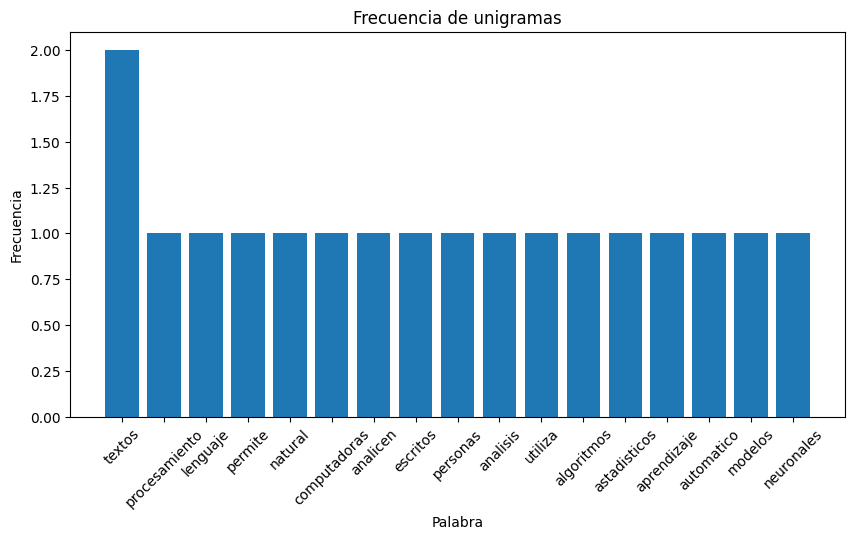

In [24]:
plt.figure(figsize=(10, 5))

plt.bar(
    df['Palabra'],
    df["Frecuencia"]
)

plt.xticks(rotation=45)
plt.title("Frecuencia de unigramas")
plt.xlabel('Palabra')
plt.ylabel('Frecuencia')

plt.show()

· Nube de palabras.

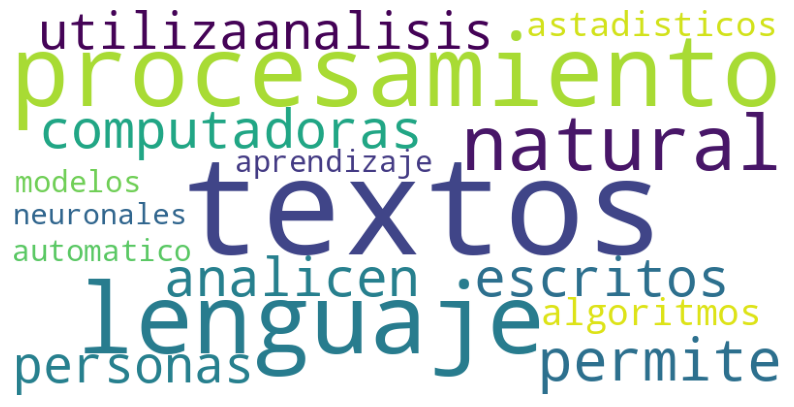

In [16]:
texto_wc = " ".join(tokens_filtrado)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(texto_wc)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()